# 01 — Exploratory Data Analysis

F1 Pit Stop Prediction · Kaggle Playground Series S6E5

**Goal**: Understand the data distribution, class balance, 2023 anomaly, tyre degradation patterns, and race progress dynamics before feature engineering.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data import load_train, load_test, load_external, dedup_external

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

train = load_train()
test = load_test()
ext_raw = load_external()
ext = dedup_external(train, ext_raw)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'External (raw): {ext_raw.shape}  |  unique: {ext.shape}')

Train shape : (439140, 16)
Test shape  : (188165, 15)
External (raw): (101371, 16)  |  unique: (76929, 16)


## 1. Basic overview

In [2]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
train.dtypes

id                          int64
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

In [4]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
# Missing values
missing = train.isnull().sum()
print('Missing values in train:')
print(missing[missing > 0])

Missing values in train:
Series([], dtype: int64)


## 2. Class balance

Overall PitNextLap positive rate: 0.1990 (19.9%)
PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64


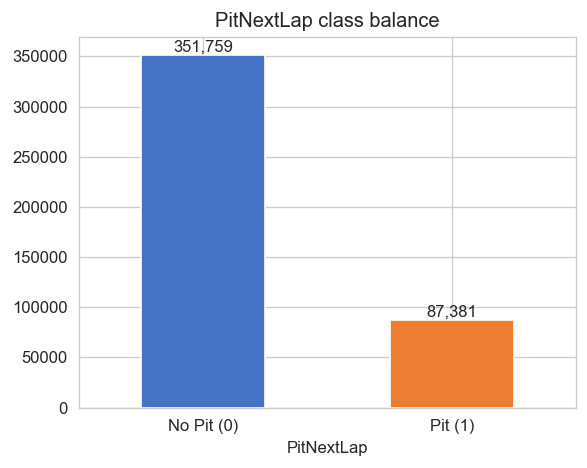

In [6]:
pos_rate = train['PitNextLap'].mean()
print(f'Overall PitNextLap positive rate: {pos_rate:.4f} ({pos_rate*100:.1f}%)')
print(train['PitNextLap'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
train['PitNextLap'].value_counts().plot(kind='bar', ax=ax, color=['#4472C4', '#ED7D31'])
ax.set_title('PitNextLap class balance')
ax.set_xticklabels(['No Pit (0)', 'Pit (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. The 2023 Year Anomaly (critical)

        rows  pit_rate  pitstop_rate
Year                                
2022   82989    0.2665        0.1865
2023  136147    0.0096        0.0124
2024  127110    0.2953        0.1922
2025   92894    0.2844        0.1957


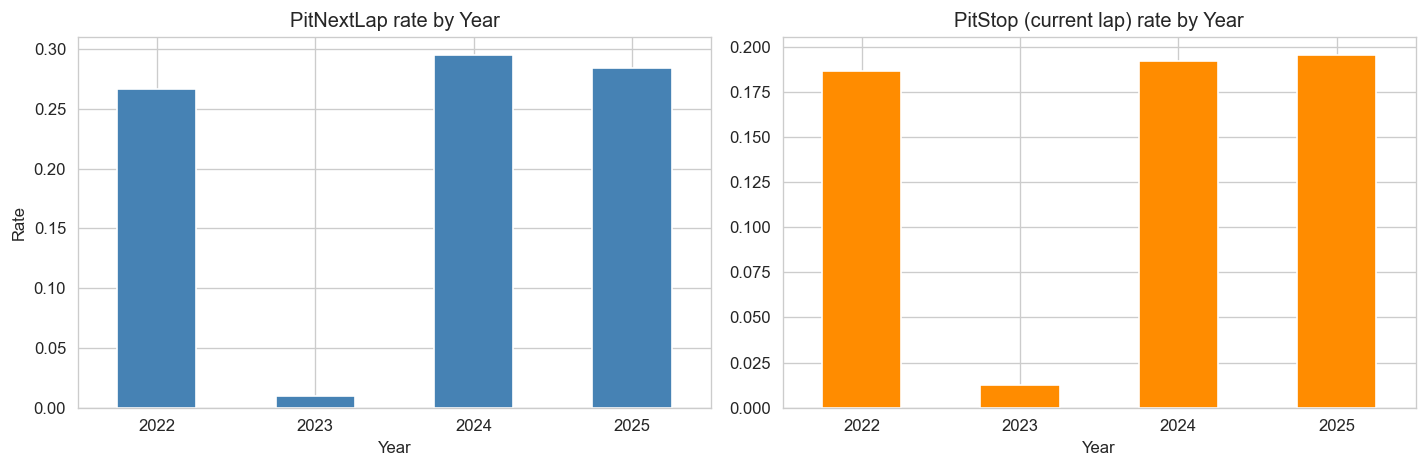

NOTE: 2023 has anomalously low pit rates — synthetic generation artifact. is_year2023 will be the most important feature.


In [7]:
year_stats = train.groupby('Year').agg(
    rows=('PitNextLap', 'count'),
    pit_rate=('PitNextLap', 'mean'),
    pitstop_rate=('PitStop', 'mean')
).round(4)
print(year_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
year_stats['pit_rate'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('PitNextLap rate by Year')
axes[0].set_ylabel('Rate')
axes[0].set_xticklabels(year_stats.index, rotation=0)

year_stats['pitstop_rate'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('PitStop (current lap) rate by Year')
axes[1].set_xticklabels(year_stats.index, rotation=0)
plt.tight_layout()
plt.show()
print('NOTE: 2023 has anomalously low pit rates — synthetic generation artifact. is_year2023 will be the most important feature.')

In [8]:
# Test set year distribution
print('Test set Year distribution:')
print(test['Year'].value_counts().sort_index())

Test set Year distribution:
Year
2022    35348
2023    58160
2024    54532
2025    40125
Name: count, dtype: int64


## 4. Tyre life vs pit decision by compound

In [9]:
compounds = train['Compound'].dropna().unique()
print('Compounds:', sorted(compounds))
print(train['Compound'].value_counts())

Compounds: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64


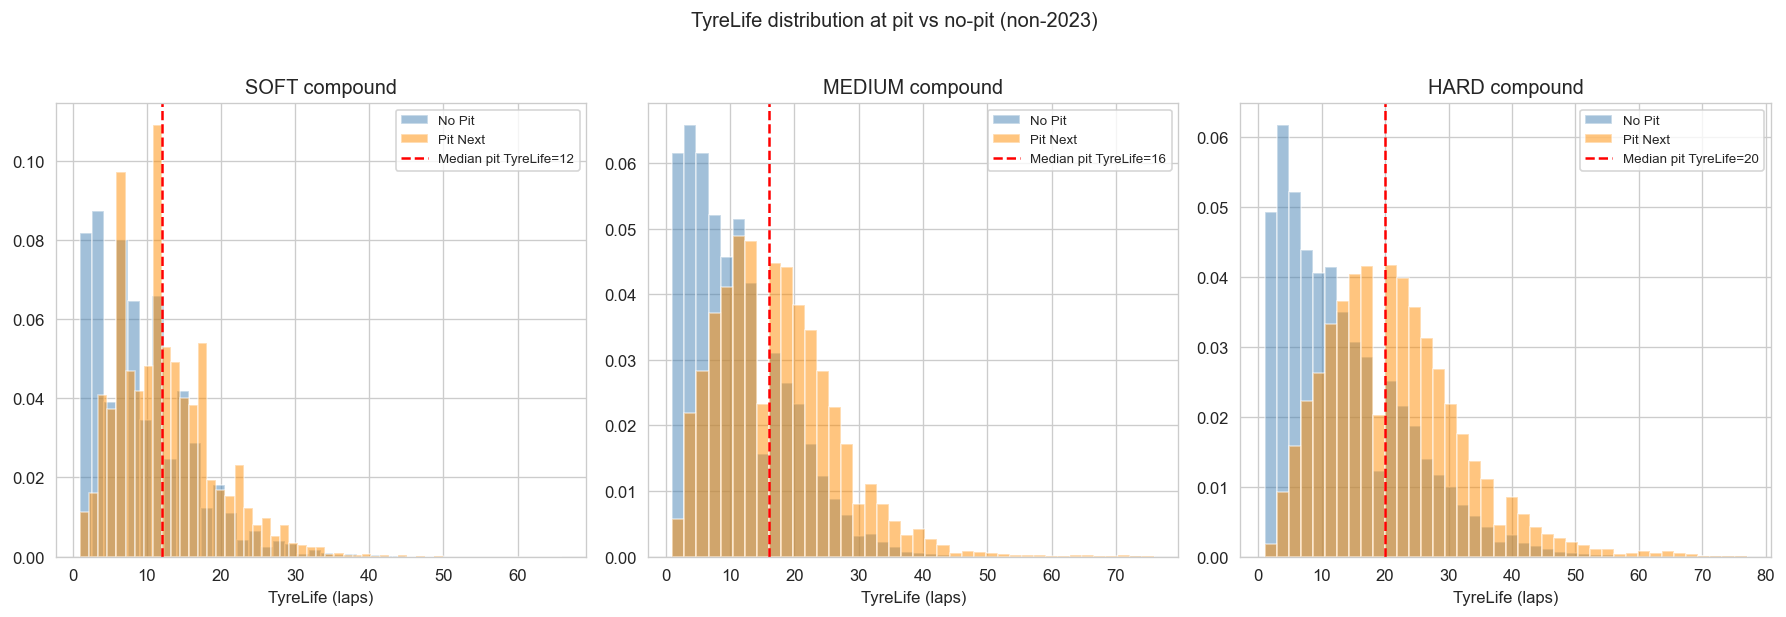

In [10]:
# Exclude 2023 for cleaner signal
non2023 = train[train['Year'] != 2023]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, compound in enumerate(['SOFT', 'MEDIUM', 'HARD']):
    subset = non2023[non2023['Compound'] == compound]
    subset[subset['PitNextLap'] == 0]['TyreLife'].hist(
        ax=axes[i], bins=40, alpha=0.5, label='No Pit', density=True, color='steelblue')
    subset[subset['PitNextLap'] == 1]['TyreLife'].hist(
        ax=axes[i], bins=40, alpha=0.5, label='Pit Next', density=True, color='darkorange')
    median_pit = subset[subset['PitNextLap'] == 1]['TyreLife'].median()
    axes[i].axvline(median_pit, color='red', linestyle='--', label=f'Median pit TyreLife={median_pit:.0f}')
    axes[i].set_title(f'{compound} compound')
    axes[i].set_xlabel('TyreLife (laps)')
    axes[i].legend(fontsize=8)
plt.suptitle('TyreLife distribution at pit vs no-pit (non-2023)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Race progress and pit timing

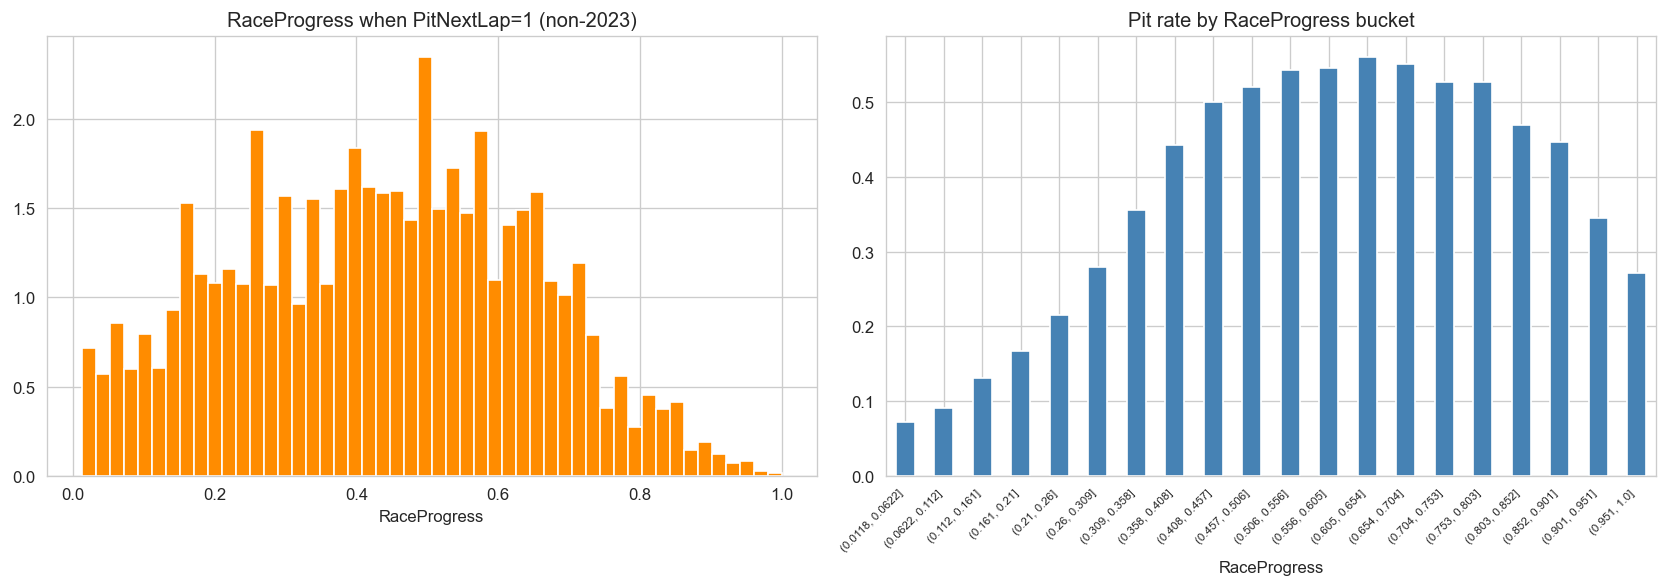

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
non2023[non2023['PitNextLap'] == 1]['RaceProgress'].hist(
    bins=50, ax=axes[0], color='darkorange', density=True)
axes[0].set_title('RaceProgress when PitNextLap=1 (non-2023)')
axes[0].set_xlabel('RaceProgress')

rp_bins = pd.cut(non2023['RaceProgress'], bins=20)
pit_by_rp = non2023.groupby(rp_bins)['PitNextLap'].mean()
pit_by_rp.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Pit rate by RaceProgress bucket')
axes[1].set_xticklabels([str(b) for b in pit_by_rp.index], rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 6. Cumulative degradation distribution

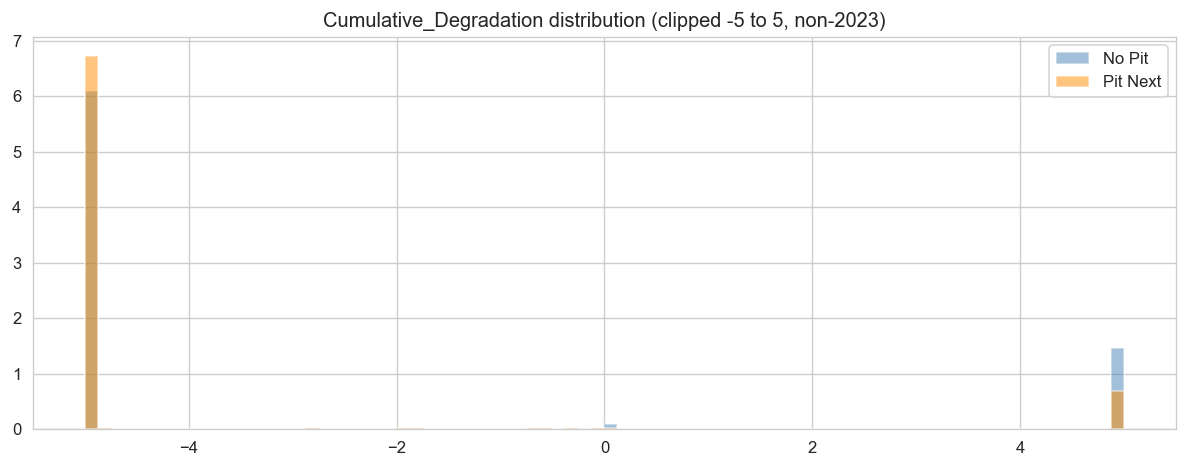

Fraction of rows with negative Cumulative_Degradation: 0.856


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
non2023[non2023['PitNextLap'] == 0]['Cumulative_Degradation'].clip(-5, 5).hist(
    bins=80, alpha=0.5, label='No Pit', density=True, color='steelblue', ax=ax)
non2023[non2023['PitNextLap'] == 1]['Cumulative_Degradation'].clip(-5, 5).hist(
    bins=80, alpha=0.5, label='Pit Next', density=True, color='darkorange', ax=ax)
ax.set_title('Cumulative_Degradation distribution (clipped -5 to 5, non-2023)')
ax.legend()
plt.tight_layout()
plt.show()

neg_pct = (train['Cumulative_Degradation'] < 0).mean()
print(f'Fraction of rows with negative Cumulative_Degradation: {neg_pct:.3f}')

## 7. Lap time trends

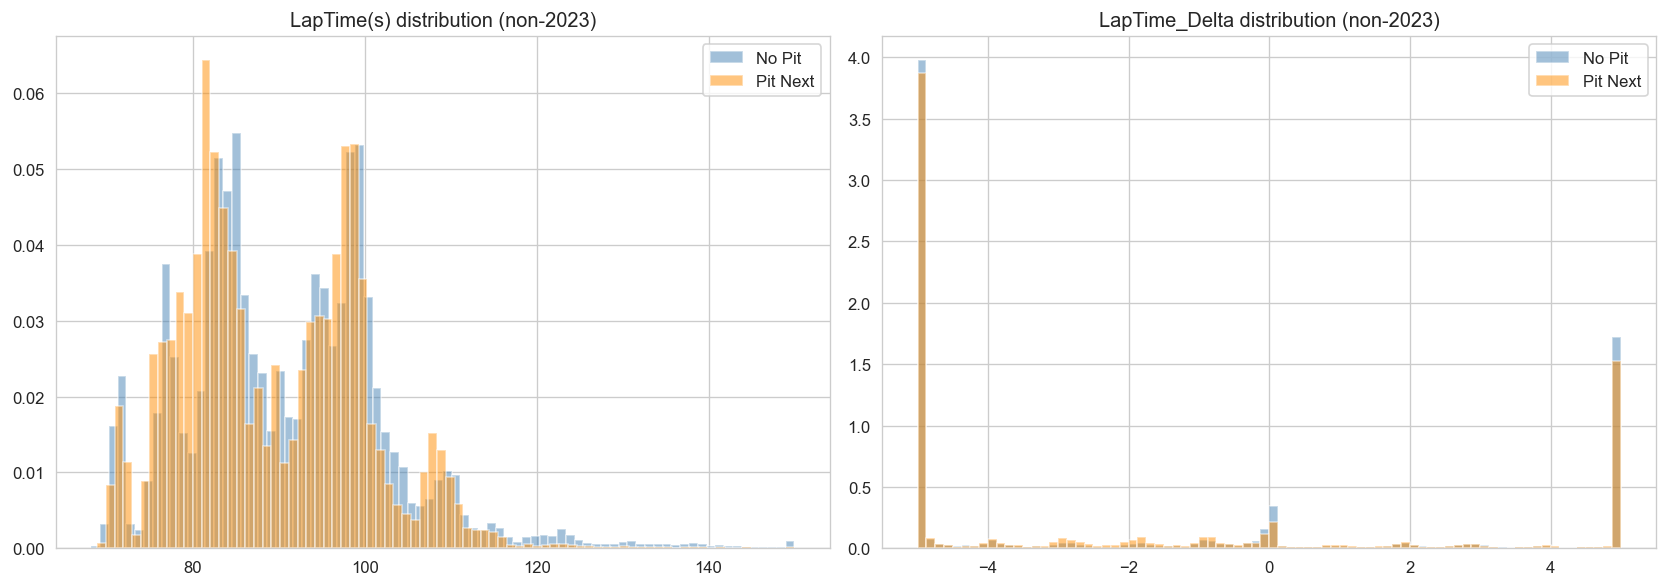

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

non2023[non2023['PitNextLap'] == 0]['LapTime (s)'].clip(60, 150).hist(
    bins=80, alpha=0.5, label='No Pit', density=True, color='steelblue', ax=axes[0])
non2023[non2023['PitNextLap'] == 1]['LapTime (s)'].clip(60, 150).hist(
    bins=80, alpha=0.5, label='Pit Next', density=True, color='darkorange', ax=axes[0])
axes[0].set_title('LapTime(s) distribution (non-2023)')
axes[0].legend()

non2023[non2023['PitNextLap'] == 0]['LapTime_Delta'].clip(-5, 5).hist(
    bins=80, alpha=0.5, label='No Pit', density=True, color='steelblue', ax=axes[1])
non2023[non2023['PitNextLap'] == 1]['LapTime_Delta'].clip(-5, 5).hist(
    bins=80, alpha=0.5, label='Pit Next', density=True, color='darkorange', ax=axes[1])
axes[1].set_title('LapTime_Delta distribution (non-2023)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Driver encoding analysis

In [14]:
import re
real_drivers = train[~train['Driver'].astype(str).str.match(r'^D\d+$')]['Driver'].unique()
enc_drivers = train[train['Driver'].astype(str).str.match(r'^D\d+$')]['Driver'].unique()
print(f'Real driver abbreviations: {len(real_drivers)}')
print(f'Encoded driver IDs (Dxxx): {len(enc_drivers)}')
print('Sample real:', sorted(real_drivers)[:10])
print('Sample encoded:', sorted(enc_drivers)[:10])

Real driver abbreviations: 131
Encoded driver IDs (Dxxx): 756
Sample real: ['ALB', 'ALE', 'ALG', 'ALO', 'AND', 'ANT', 'ARN', 'BAD', 'BAR', 'BAT']
Sample encoded: ['D001', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008', 'D009', 'D010']


## 9. External dataset overview

In [15]:
print(f'External dataset shape (raw): {ext_raw.shape}')
print(f'External dataset shape (after dedup): {ext.shape}')
print(f'Overlap removed: {len(ext_raw) - len(ext):,} rows')
print(f'\nExternal PitNextLap rate: {ext["PitNextLap"].mean():.4f}')
print(f'Train PitNextLap rate:    {train["PitNextLap"].mean():.4f}')
print(f'\nExternal columns not in train: {set(ext.columns) - set(train.columns)}')

External dataset shape (raw): (101371, 16)
External dataset shape (after dedup): (76929, 16)
Overlap removed: 24,442 rows

External PitNextLap rate: 0.2624
Train PitNextLap rate:    0.1990

External columns not in train: {'Normalized_TyreLife'}


## 10. Feature correlations with target

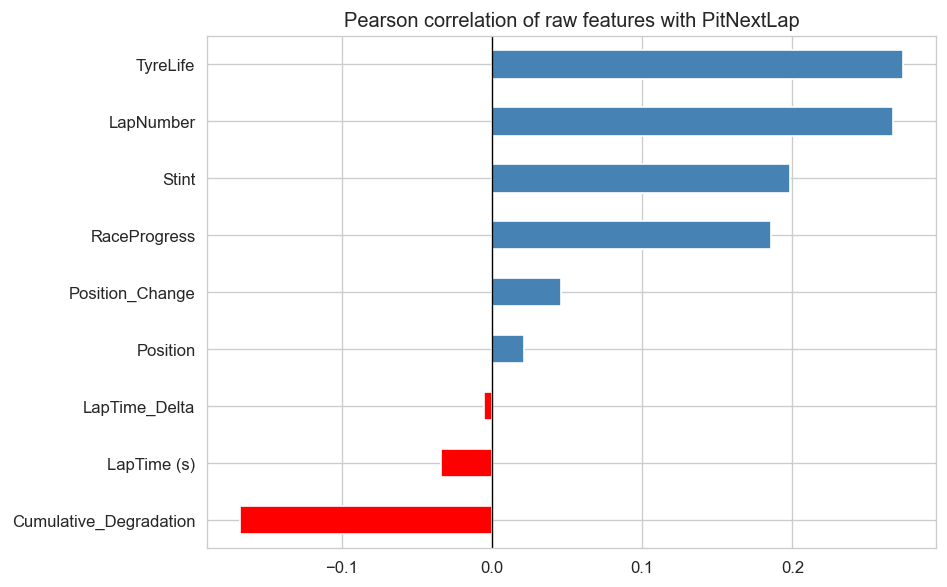

Cumulative_Degradation   -0.167401
LapTime (s)              -0.034096
LapTime_Delta            -0.004946
Position                  0.021348
Position_Change           0.046230
RaceProgress              0.185477
Stint                     0.198193
LapNumber                 0.267057
TyreLife                  0.273510
Name: PitNextLap, dtype: float64


In [16]:
num_cols = ['TyreLife', 'Stint', 'LapNumber', 'Position', 'RaceProgress',
            'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change']

corrs = train[num_cols + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot(kind='barh', ax=ax, color=['red' if c < 0 else 'steelblue' for c in corrs])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation of raw features with PitNextLap')
plt.tight_layout()
plt.show()
print(corrs)

## 11. Race-level pit strategy variation

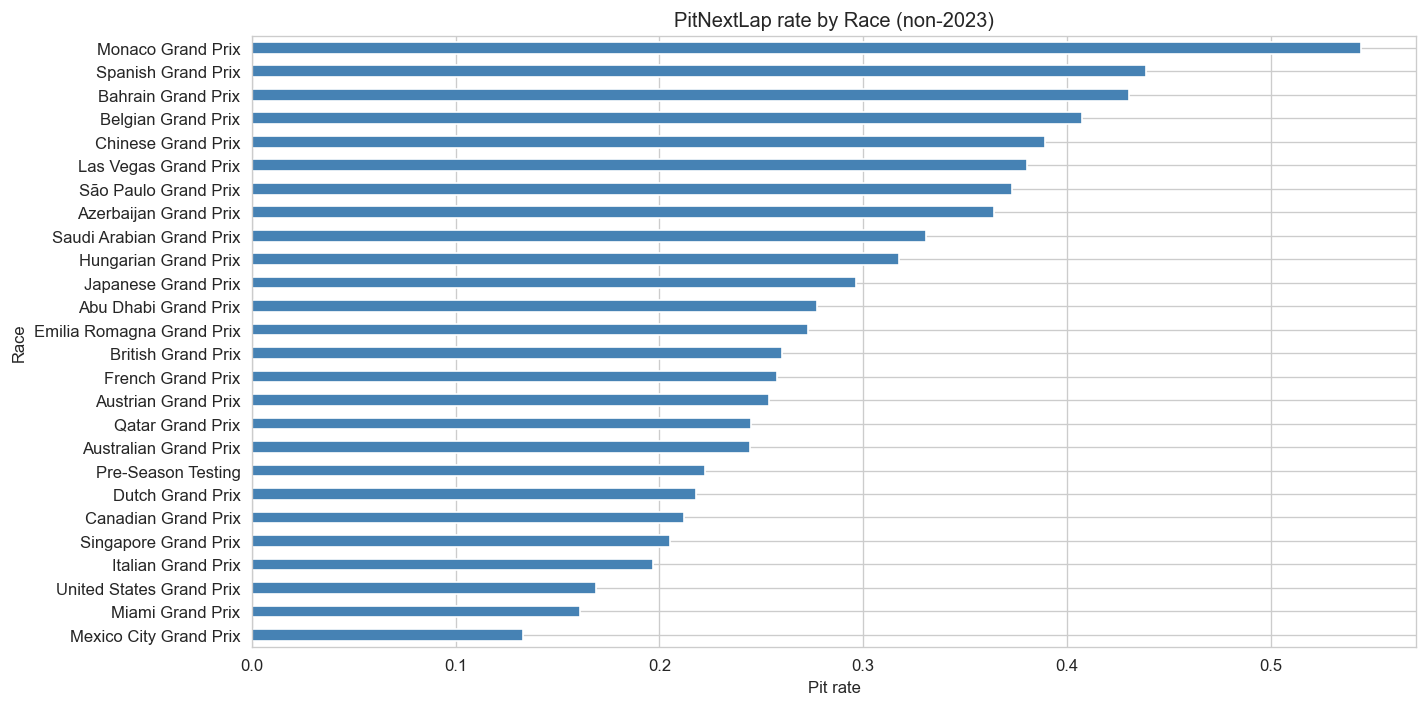

In [17]:
race_pit_rate = (non2023.groupby('Race')['PitNextLap'].mean()
                 .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(12, 6))
race_pit_rate.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('PitNextLap rate by Race (non-2023)')
ax.set_xlabel('Pit rate')
plt.tight_layout()
plt.show()

## Summary

Key findings:
- **2023 anomaly confirmed**: ~1% pit rate vs 25-30% other years → `is_year2023` is critical
- **Class imbalance**: ~20% overall positive rate (masks 2023 anomaly)
- **TyreLife thresholds**: SOFT pits ~12 laps, MEDIUM ~16, HARD ~20 — not sharp cutoffs
- **Race progress**: Pit peak at 0.4–0.7, drops after 0.8
- **External data**: 25.5% pit rate vs 19.9% train — distribution shift to handle
- **Driver encoding**: 2 types (real 3-letter vs Dxxx encoded) → `is_real_driver` flag needed